### Customer Churn Prediction
##### Exploratory Data Analysis

### Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [38]:
df = pd.read_csv("../data/telco_customer_churn.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
# Dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [40]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [41]:
# Check blank values in TotalCharges
(df['TotalCharges'].str.strip() == '').sum()

np.int64(11)

In [42]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values after conversion
df['TotalCharges'].isnull().sum()

np.int64(11)

In [43]:
# Remove rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Verify dataset shape
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [44]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [45]:
# Check target distribution
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [46]:
# Check target distribution (%)
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [48]:
import os
print(os.getcwd())

c:\Users\paris\Desktop\customer-churn-prediction-main\notebooks


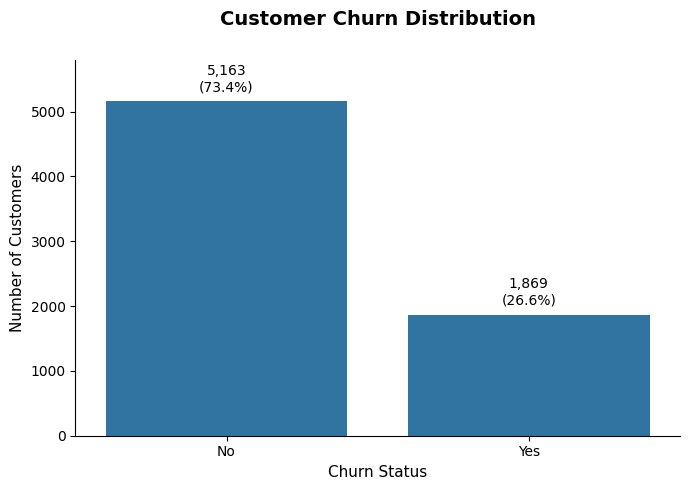

In [53]:
# Customer Churn Distribution

# Create figure
plt.figure(figsize=(7, 5))

# Create count plot
ax = sns.countplot(data=df, x='Churn')

# Add title and axis labels
plt.title(
    'Customer Churn Distribution',
    fontsize=14,
    fontweight='bold',
    pad=25
)

plt.xlabel('Churn Status', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)

# Add customer count and percentage above each bar
for container in ax.containers:
    labels = [
        f'{int(bar.get_height()):,}\n({bar.get_height() / len(df) * 100:.1f}%)'
        for bar in container
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        padding=5,
        fontsize=10
    )

# Add extra space above bars
plt.ylim(0, 5800)

# Clean chart appearance
sns.despine()

# Adjust layout
plt.tight_layout()

# Save chart for README
plt.savefig(
    '../images/churn_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

# Display chart
plt.show()

## Churn Drivers Analysis

To better understand customer churn, we examine how churn varies across key customer characteristics, including contract type, tenure, monthly charges, and internet service.

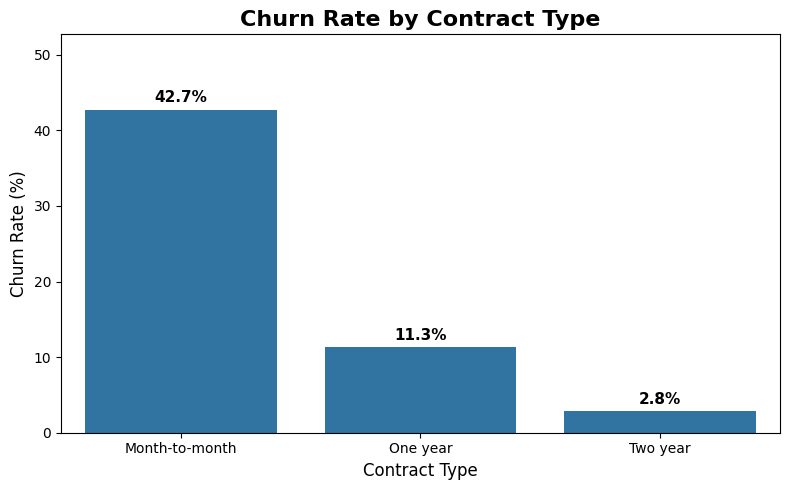

In [55]:
# Churn rate by contract type

contract_churn = (
    df.groupby('Contract')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)

# Add percentage labels
for i, value in enumerate(contract_churn.values):
    plt.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, max(contract_churn.values) + 10)
plt.tight_layout()

plt.savefig(
    '../images/churn_by_contract.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Finding

Customers with **month-to-month contracts have the highest churn rate (42.7%)**, compared with **11.3% for one-year contracts** and only **2.8% for two-year contracts**.

This suggests that **longer-term contracts are strongly associated with higher customer retention**.

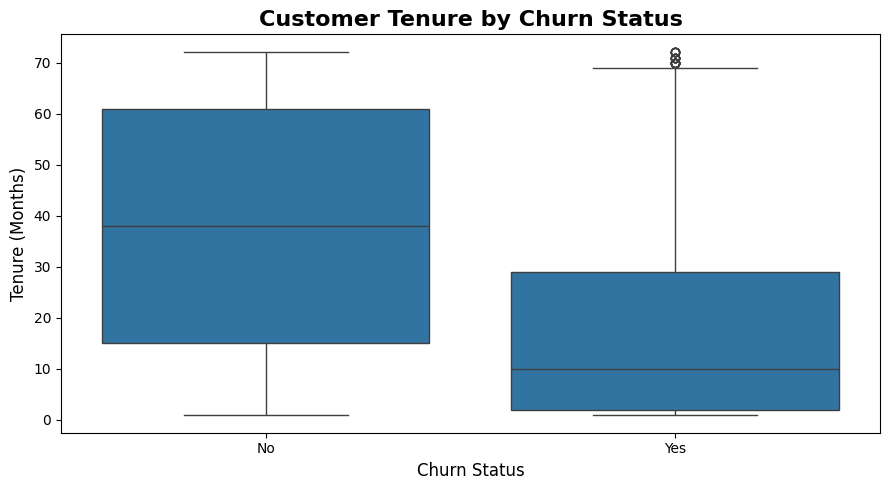

In [56]:
# Tenure distribution by churn status

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Customer Tenure by Churn Status',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)

plt.tight_layout()

plt.savefig(
    '../images/tenure_by_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Finding

Customers who churn tend to have **substantially shorter tenure** than customers who remain.

The median tenure of churned customers is approximately **10 months**, compared with approximately **38 months** for retained customers.

This suggests that **newer customers are at greater risk of churn**, highlighting the importance of customer retention strategies during the early stages of the customer relationship.

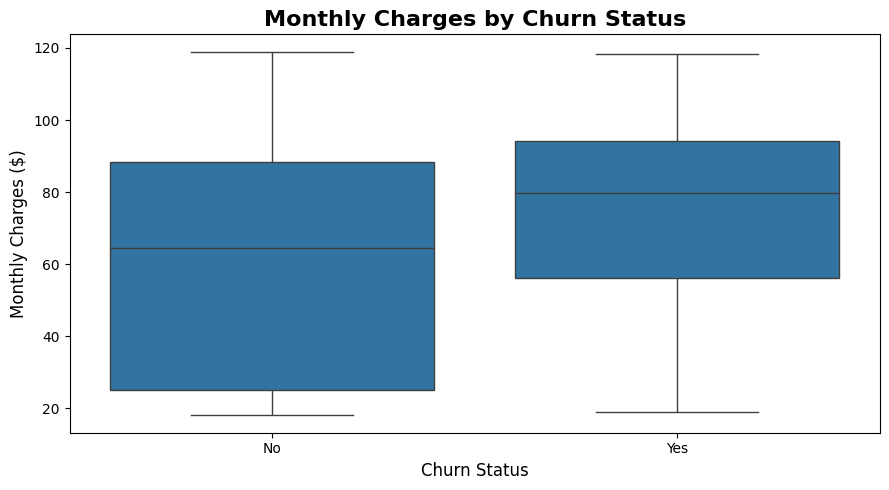

In [58]:
# Monthly charges distribution by churn status

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title(
    'Monthly Charges by Churn Status',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)

plt.tight_layout()

plt.savefig(
    '../images/monthly_charges_by_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Finding

Customers who churn tend to have **higher monthly charges** than customers who remain.

The distribution of monthly charges is shifted upward for churned customers, suggesting that **higher monthly costs are associated with an increased likelihood of churn**.

This suggests that monthly charges may be a useful feature for predicting customer churn.

## Key Observation

The target variable is moderately imbalanced, with approximately 73% of customers retained and 27% having churned. This class imbalance should be considered during model evaluation.